# Code Review Agent — Graph Exploration

Use this notebook to:
1. Visualise the LangGraph graph structure
2. Run the agent end-to-end against a real PR (or a mock one)
3. Inspect state at each step

> **Kernel:** select `Code Review Agent` from the kernel picker.

In [36]:
import sys, pathlib
# Make sure the src package is importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

In [37]:
from dotenv import load_dotenv
load_dotenv(dotenv_path='../.env')  # loads ANTHROPIC_API_KEY, GITHUB_TOKEN, etc.

True

## 1. Build & visualise the graph

In [38]:
from code_review_agent.graph import build_graph

graph = build_graph()
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__(<p>__start__</p>)
	fetch_pr(fetch_pr)
	load_context(load_context)
	bug_agent(bug_agent)
	security_agent(security_agent)
	style_agent(style_agent)
	aggregate(aggregate)
	reflect(reflect)
	human_approval(human_approval<hr/><small><em>__interrupt = before</em></small>)
	post_review(post_review)
	__end__(<p>__end__</p>)
	__start__ --> fetch_pr;
	aggregate --> reflect;
	bug_agent --> aggregate;
	fetch_pr --> load_context;
	load_context --> bug_agent;
	load_context --> security_agent;
	load_context --> style_agent;
	reflect --> human_approval;
	security_agent --> aggregate;
	style_agent --> aggregate;
	human_approval --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



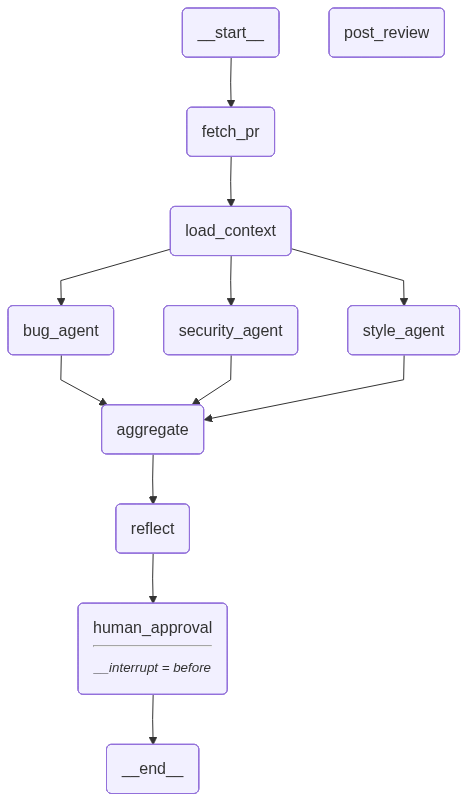

In [39]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 2. Run against a real PR

Replace `PR_URL` with any public GitHub PR you want to review.

In [41]:
import os
import uuid

PR_URL = 'https://github.com/sandaruwan98/pagero-labs-custom-text-area/pull/11' 

run_config = {
    'configurable': {
        'thread_id': str(uuid.uuid4()),
        'anthropic_api_key': os.environ['ANTHROPIC_API_KEY'],
        'github_token': os.environ['GITHUB_TOKEN'],
        'model_name': 'claude-sonnet-4-20250514',
        'min_severity': os.getenv('MIN_SEVERITY', 'minor'),
        'post_to_github': False,  # always dry-run from the notebook
    }
}

In [42]:
# Run up to the human_approval interrupt
initial_state = {'pr_url': PR_URL, 'findings': [], 'token_usage': {}}

result = graph.invoke(initial_state, config=run_config)
print('Graph paused at human_approval checkpoint.')

Graph paused at human_approval checkpoint.


In [ ]:
import json

state_snapshot = graph.get_state(run_config)
comments = state_snapshot.values.get('final_comments', [])
print(f'{len(comments)} finding(s):\n')
print(json.dumps(comments, indent=2))

12 finding(s):

[
  {
    "file": "src/custom-text-area/TextArea.tsx",
    "line": 24,
    "severity": "critical",
    "category": "bug",
    "message": "`useEffect` has an empty dependency array `[]`, so the ResizeObserver is only set up once on mount. `textAreaElement`, `preElement`, and `codeElement` are plain `let` variables (not refs), so they are stale inside the effect closure after re-renders. Additionally, the `validationHelper` used in closures is recreated on every render but the effect never re-runs to pick up the new instance.",
    "suggestion": "Convert `textAreaElement`, `preElement`, and `codeElement` to `useRef` hooks so their values persist across renders and are reliably available inside effects and callbacks. Wrap `validationHelper` in `useMemo` keyed on `type` to stabilise the instance."
  },
  {
    "file": "src/custom-text-area/TextArea.tsx",
    "line": 34,
    "severity": "critical",
    "category": "security",
    "message": "Direct assignment to `innerHTML` 

In [46]:
print(json.dumps(state_snapshot.values.get('findings', []), indent=2))

[
  {
    "file": "src/App.js",
    "line": 16,
    "severity": "minor",
    "category": "bug",
    "message": "Using `selected` attribute directly on an `<option>` in a controlled React component is incorrect. React uses the `value` prop on `<select>` to control selection; the `selected` attribute on `<option>` is ignored and will produce a React warning.",
    "suggestion": "Remove the `selected` attribute from the `<option value=\"text\">` element. The controlled `value={selectedValue}` on the `<select>` already handles the default selection."
  },
  {
    "file": "src/custom-text-area/TextArea.tsx",
    "line": 12,
    "severity": "major",
    "category": "bug",
    "message": "When `type` is neither 'json' nor 'xml' (e.g., the default 'text'), `XmlValidationHelper` is used as a fallback. This means text mode is validated/formatted as XML, which is incorrect behavior.",
    "suggestion": "Add a dedicated `TextValidationHelper` for the 'text' type, or add an explicit check: `type ==

In [47]:
# Token usage so far
print(json.dumps(state_snapshot.values.get('token_usage', {}), indent=2))

{
  "security_agent": {
    "input": 5386,
    "output": 350
  },
  "bug_agent": {
    "input": 5286,
    "output": 1018
  },
  "style_agent": {
    "input": 5400,
    "output": 1556
  },
  "reflect": {
    "input": 3182,
    "output": 1809
  }
}


## 3. Human-in-the-loop: approve or reject

In [48]:
# Approve → the graph will proceed to post_review
graph.update_state(
    run_config,
    {'human_approved': True, 'human_feedback': None},
    as_node='human_approval',
)

# Resume execution
final = graph.invoke(None, config=run_config)
print('Done.')


[dry-run] Would post the following review:

🔴 **CRITICAL** 🐛 `bug`

`useEffect` has an empty dependency array `[]`, so the ResizeObserver is only set up once on mount. `textAreaElement`, `preElement`, and `codeElement` are plain `let` variables (not refs), so they are stale inside the effect closure after re-renders. Additionally, the `validationHelper` used in closures is recreated on every render but the effect never re-runs to pick up the new instance.

**Suggestion:** Convert `textAreaElement`, `preElement`, and `codeElement` to `useRef` hooks so their values persist across renders and are reliably available inside effects and callbacks. Wrap `validationHelper` in `useMemo` keyed on `type` to stabilise the instance.
---
🔴 **CRITICAL** 🔒 `security`

Direct assignment to `innerHTML` with potentially unsanitized content. The value returned by `validationHelper.formatAndValidate(text)` is set directly as `codeElement.innerHTML`, which can lead to XSS if the formatted/validated string 